# Option pricing & delta-hedging: results walkthrough

This notebook shows the main results of the project. It re-uses the code in `src/` and reads the tables and figures that `scripts/run_all.py` writes to `output/`.

**Data honesty note.** The smile and hedging experiments use *model-generated* prices and paths (Merton jump-diffusion and plain geometric Brownian motion), not market data. The sandbox that built this had no market-data access. Scripts for real data are in `scripts/real_data/`.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
import black_scholes as bs, monte_carlo as mc, binomial_tree as bt, implied_vol as iv, jump_diffusion as jd, delta_hedging as dh
R = json.loads((ROOT / "output/tables/key_results.json").read_text())
T_ = lambda n: pd.read_csv(ROOT / "output/tables" / n)
fig = lambda n: display(Image(str(ROOT / "output/figures" / n)))

## 1. Black-Scholes price and Greeks
One at-the-money call: stock 100, strike 100, 1 year, rate 5%, volatility 20%.

In [2]:
S,K,T,r,sig = 100,100,1,0.05,0.20
pd.Series({"call price":bs.call_price(S,K,T,r,sig),"put price":bs.put_price(S,K,T,r,sig),
           "delta":bs.delta(S,K,T,r,sig),"gamma":bs.gamma(S,K,T,r,sig),"vega":bs.vega(S,K,T,r,sig),
           "theta/yr":bs.theta(S,K,T,r,sig),"rho":bs.rho(S,K,T,r,sig)}).round(4)

call price    10.4506
put price      5.5735
delta          0.6368
gamma          0.0188
vega          37.5240
theta/yr      -6.4140
rho           53.2325
dtype: float64

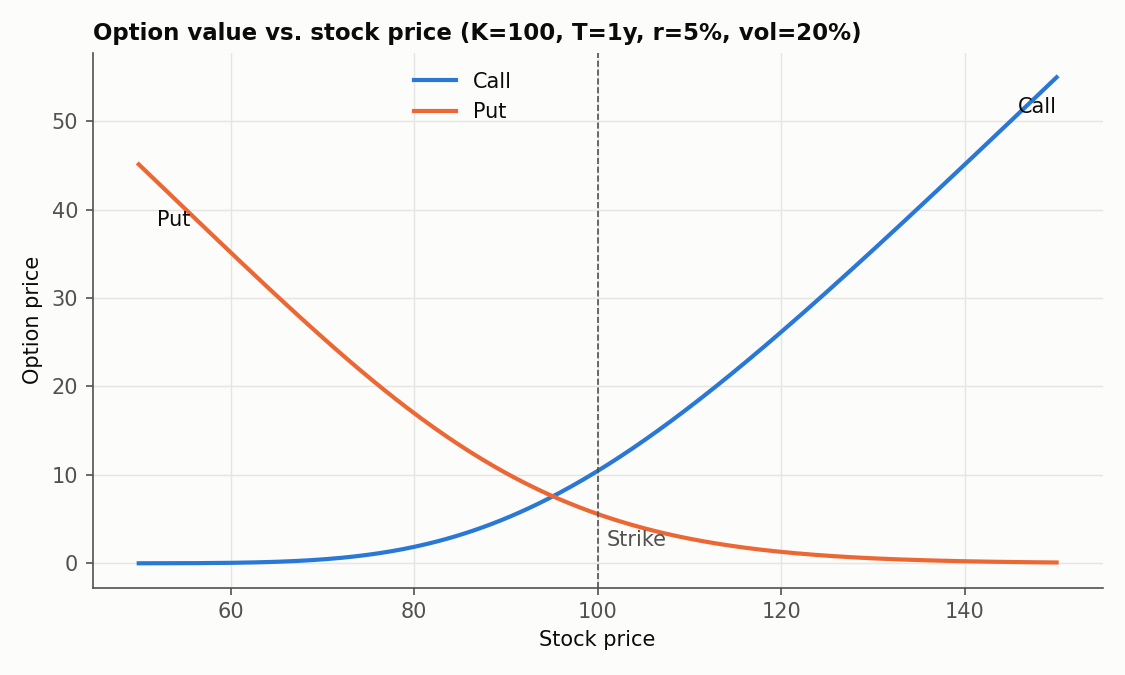

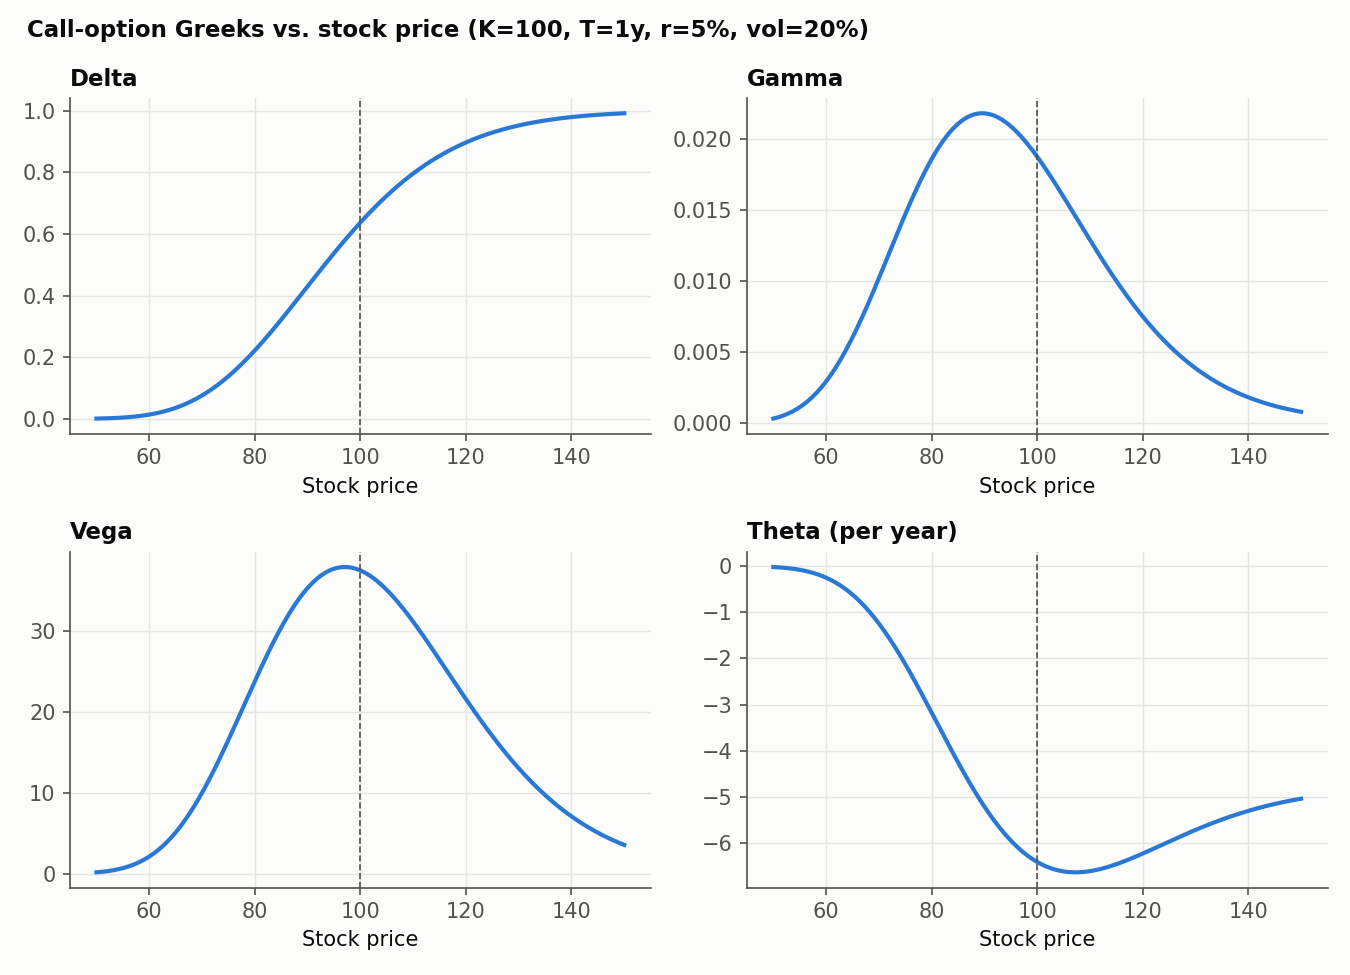

In [3]:
fig('price_vs_stock.png'); fig('greeks_vs_stock.png')

## 2. Three pricing methods agree
Closed form vs a 2,000-step binomial tree vs a 1-million-path Monte Carlo.

In [4]:
t = T_('pricing_methods_comparison.csv'); display(t.round(4))
print('put-call parity max error:', R['pricing']['put_call_parity_max_abs_error'])
print('delta analytic vs numeric:', R['pricing']['delta_analytic_vs_numeric_abs_diff'])

,option,strike,black_scholes,binomial_2000,binomial_abs_err,monte_carlo_1m,mc_std_error,mc_abs_err,mc_err_in_std_errors
0,call,90.0,16.6994,16.6997,0.0002,16.7034,0.0174,0.0039,0.2253
1,call,100.0,10.4506,10.4496,0.0010,10.4532,0.0147,0.0026,0.1773
2,call,110.0,6.0401,6.0407,0.0006,6.0440,0.0116,0.0040,0.3392
3,put,90.0,2.3101,2.3103,0.0002,2.3102,0.0054,0.0001,0.0220
4,put,100.0,5.5735,5.5725,0.0010,5.5723,0.0087,0.0012,0.1375
5,put,110.0,10.6753,10.6759,0.0006,10.6755,0.0120,0.0001,0.0124


put-call parity max error: 2.842170943040401e-14
delta analytic vs numeric: 8.274014806630703e-11


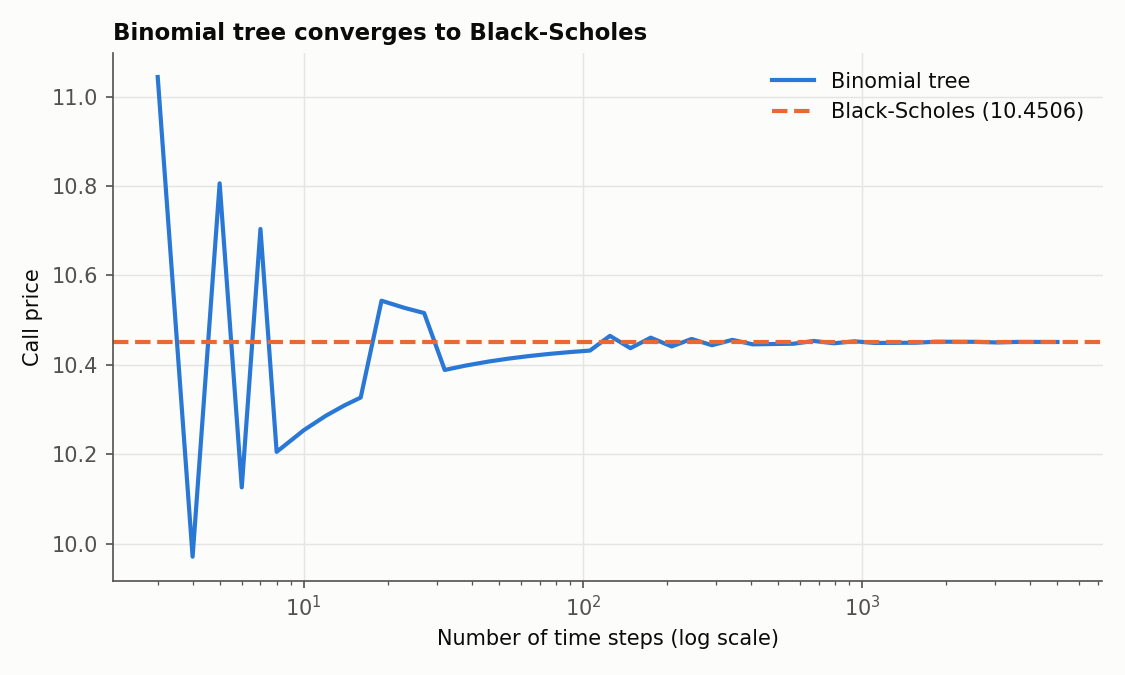

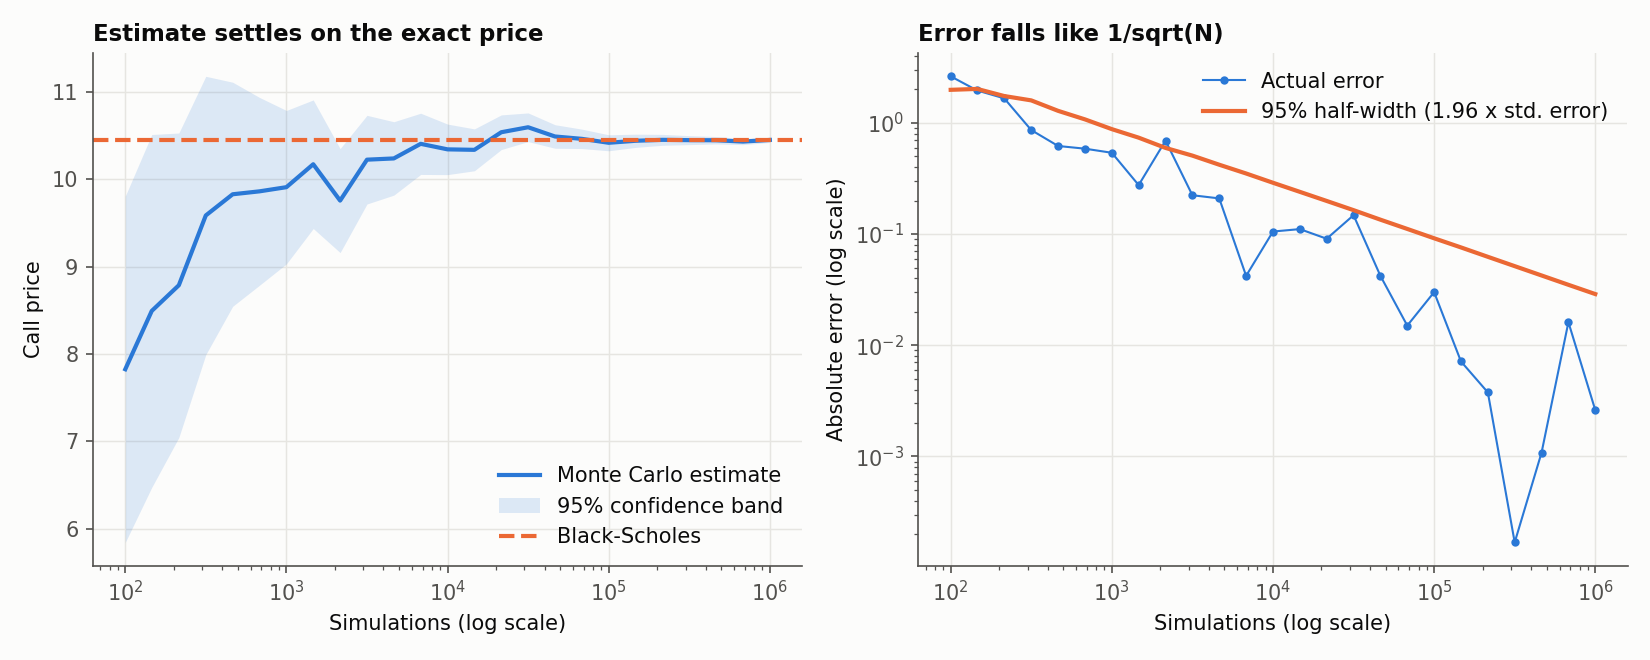

In [5]:
fig('binomial_convergence.png'); fig('monte_carlo_convergence.png')

Binomial error shrinks as steps grow; Monte Carlo error shrinks like 1/sqrt(N) (fitted log-log slope about -0.48, theory -0.5). The tree also prices **American** options, which have no closed form:

American put 6.089 vs European put 5.570 -> early-exercise premium 0.519


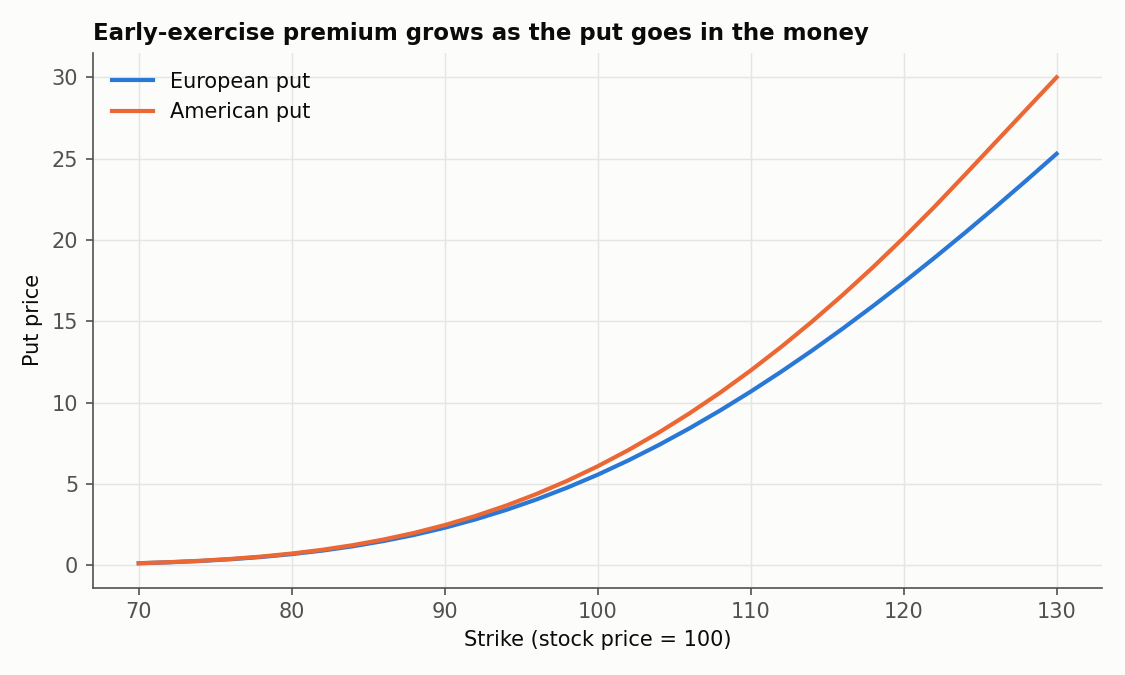

In [6]:
c = R['convergence']
print(f"American put {c['american_put_atm']:.3f} vs European put {c['european_put_atm']:.3f} -> early-exercise premium {c['early_exercise_premium_atm']:.3f}")
fig('american_vs_european_put.png')

## 3. Implied volatility and the smile (model-generated)
Prices come from a Merton jump-diffusion (diffusion vol 15%, 0.5 jumps/yr, mean jump -10%, jump st.dev. 15%). Inverting Black-Scholes on those prices gives a smile even though the model's own world has a single diffusion vol.

In [7]:
# Round-trip check: price with a known vol, recover it
p = bs.call_price(100,110,0.5,0.03,0.27); print(iv.implied_volatility(p,100,110,0.5,0.03,'call'))
s = R['smile']; print(s['data_source'])
pd.DataFrame({'ATM implied vol %':s['atm_iv_pct'],'skew 90%-110% (vol pts)':s['skew_pts_90_minus_110']}).round(2)

0.27000000000639285
Merton jump-diffusion (model-generated, not market data)


,ATM implied vol %,skew 90%-110% (vol pts)
1M,16.98,7.49
3M,17.92,3.97
6M,18.50,2.55
12M,18.97,1.52


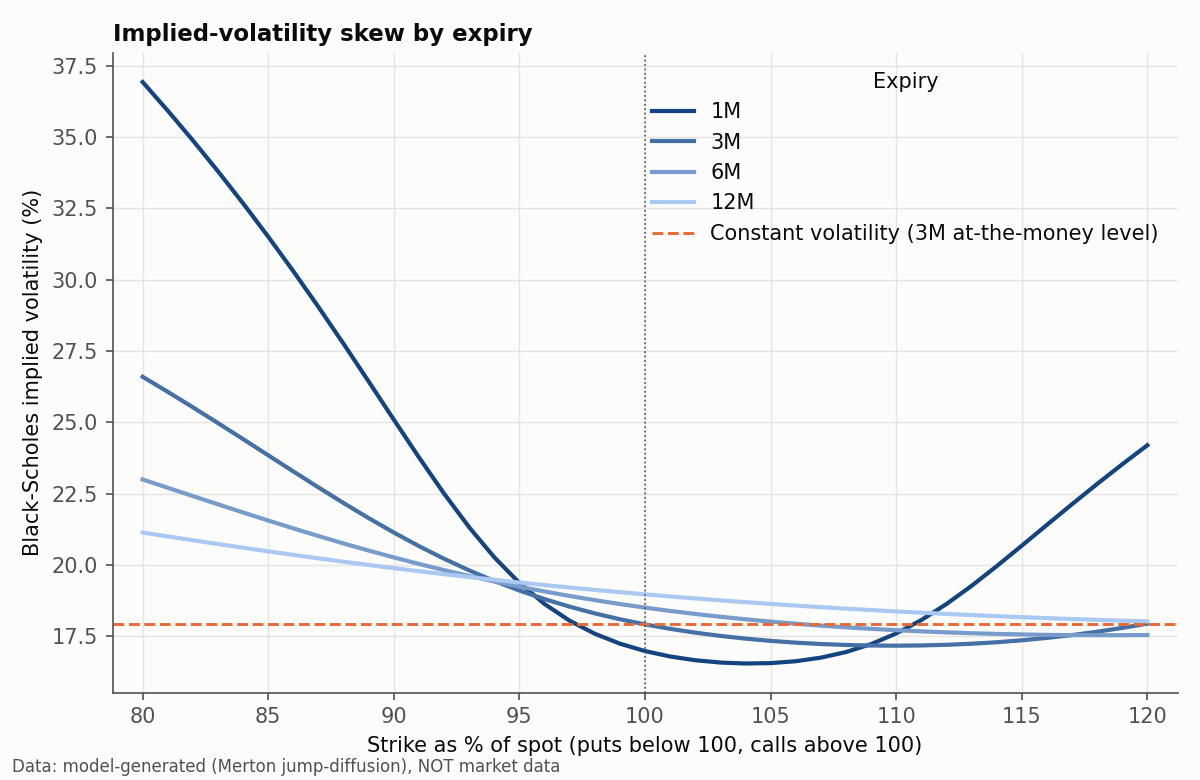

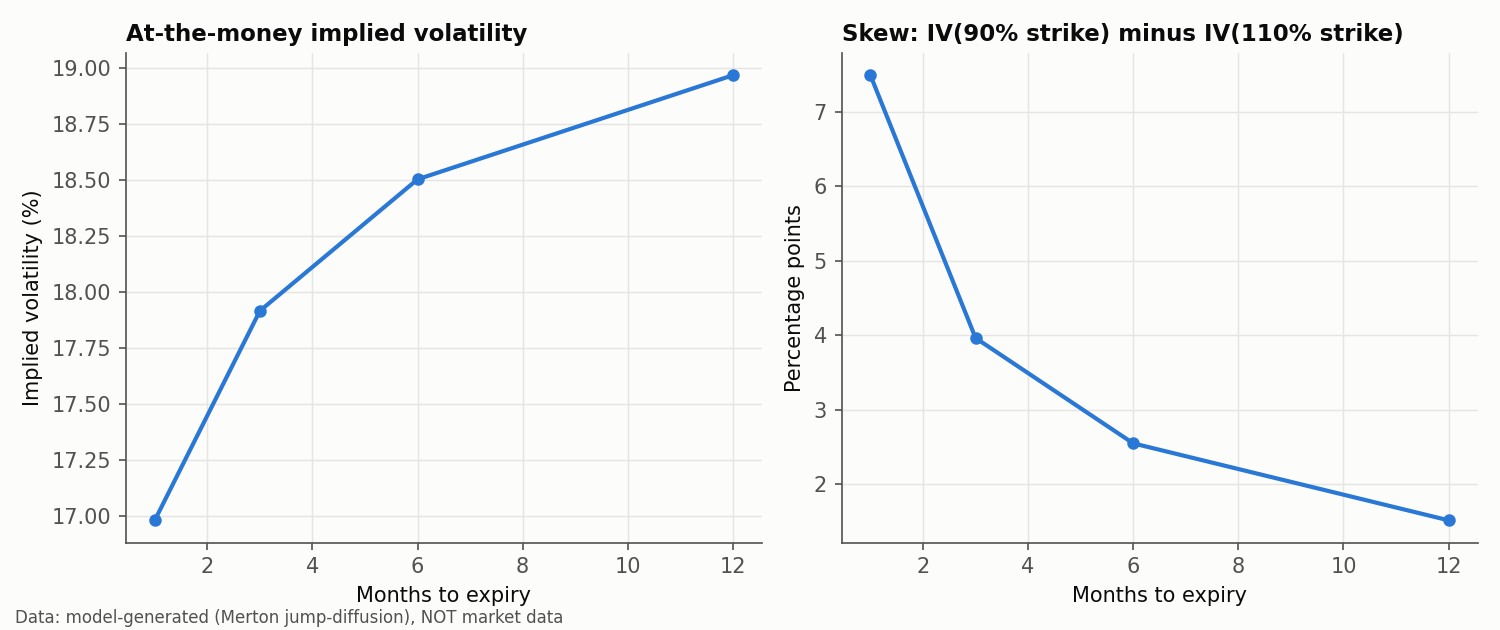

In [8]:
fig('vol_smile_model.png'); fig('vol_term_structure_model.png')

*Caution:* the rising ATM term structure here is a feature of this particular jump model, not a claim about real markets.

## 4. Delta-hedging experiments
Sell one 60-day at-the-money call, hold delta shares, rebalance, and look at the P&L at expiry (present value, per option; 40,000 simulated paths).

**A. More frequent rebalancing shrinks the error like 1/sqrt(n).**

,rebalances,mean_pnl,std_pnl,mean_se
0,2,0.0012,2.1509,0.0107
1,3,-0.0062,1.8054,0.0090
2,4,-0.0022,1.5733,0.0079
3,5,0.0025,1.4142,0.0071
4,6,-0.0080,1.3051,0.0065
5,8,-0.0047,1.1375,0.0057
6,10,-0.0020,1.0248,0.0051
7,12,-0.0094,0.9442,0.0047
8,15,-0.0085,0.8526,0.0043
9,16,-0.0050,0.8191,0.0041


log-log slope -0.479


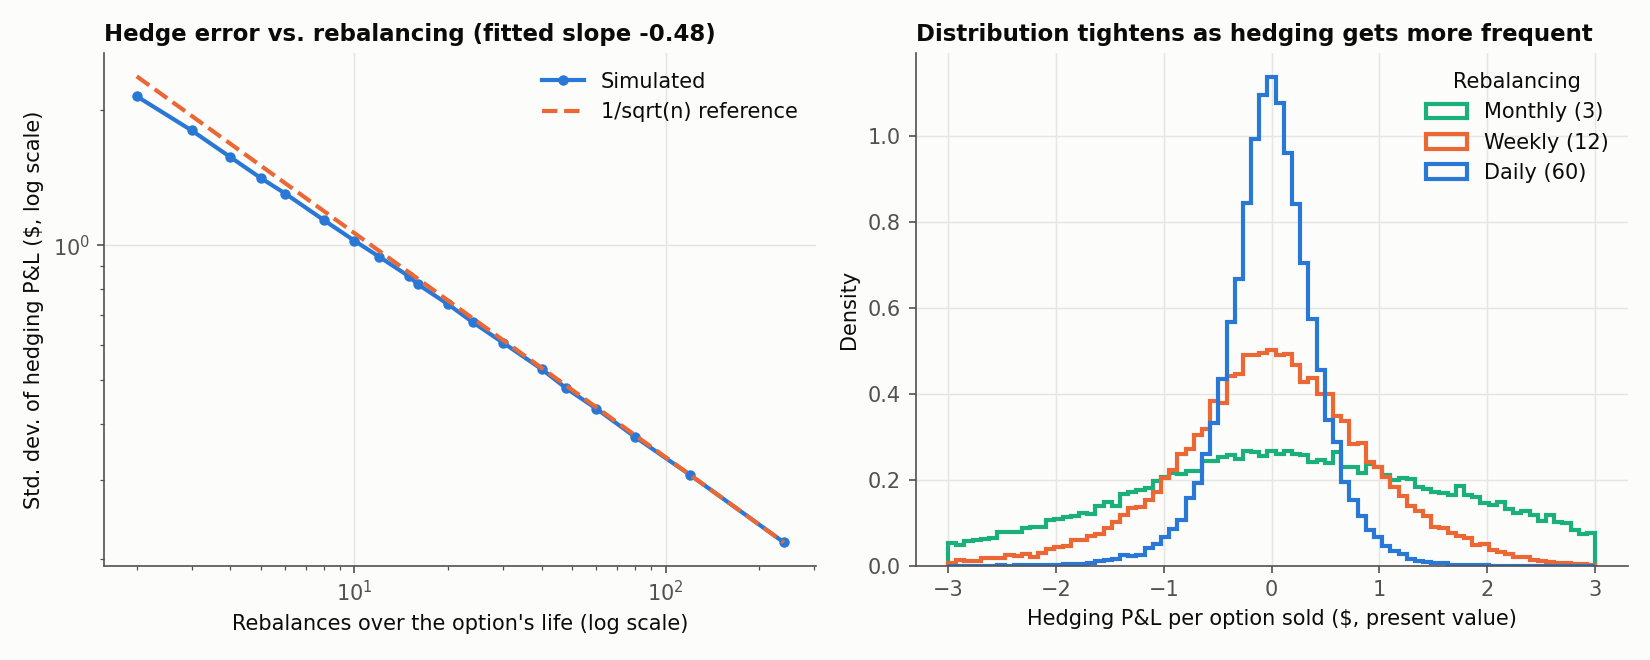

In [9]:
a = T_('hedge_A_rebalancing.csv'); display(a.round(4)); print('log-log slope', round(R['hedging']['std_vs_rebalances_loglog_slope'],3))
fig('hedge_A_rebalancing.png')

**B. Hedging at the wrong volatility gives a predictable gain or loss**, matching the P&L-attribution formula.

,hedge_vol,mean_pnl,se,std_pnl,theory_mean
0,0.100,-1.9328,0.0054,1.0704,-1.9322
1,0.125,-1.4525,0.0040,0.8036,-1.4502
2,0.150,-0.9704,0.0030,0.6023,-0.9671
3,0.175,-0.4872,0.0024,0.4748,-0.4836
4,0.200,-0.0036,0.0022,0.4321,0.0000
5,0.225,0.4802,0.0023,0.4634,0.4834
6,0.250,0.9641,0.0027,0.5367,0.9667
7,0.275,1.4479,0.0031,0.6260,1.4498
8,0.300,1.9316,0.0036,0.7182,1.9325


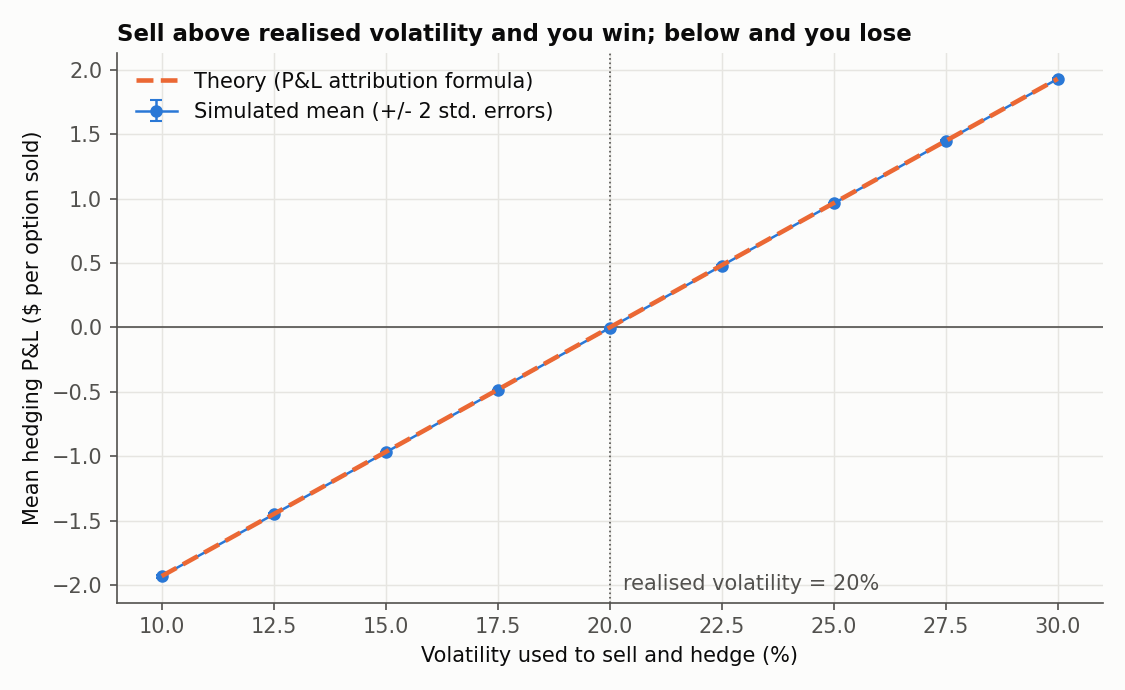

In [10]:
display(T_('hedge_B_vol_mismatch.csv').round(4)); fig('hedge_B_vol_mismatch.png')

**C. Jumps fatten the left tail.** Same total volatility, very different worst cases.

,GBM,Merton jumps
std,0.426,2.403
1st pct,-1.163,-12.221
worst,-2.724,-43.728
excess kurtosis,1.549,40.142


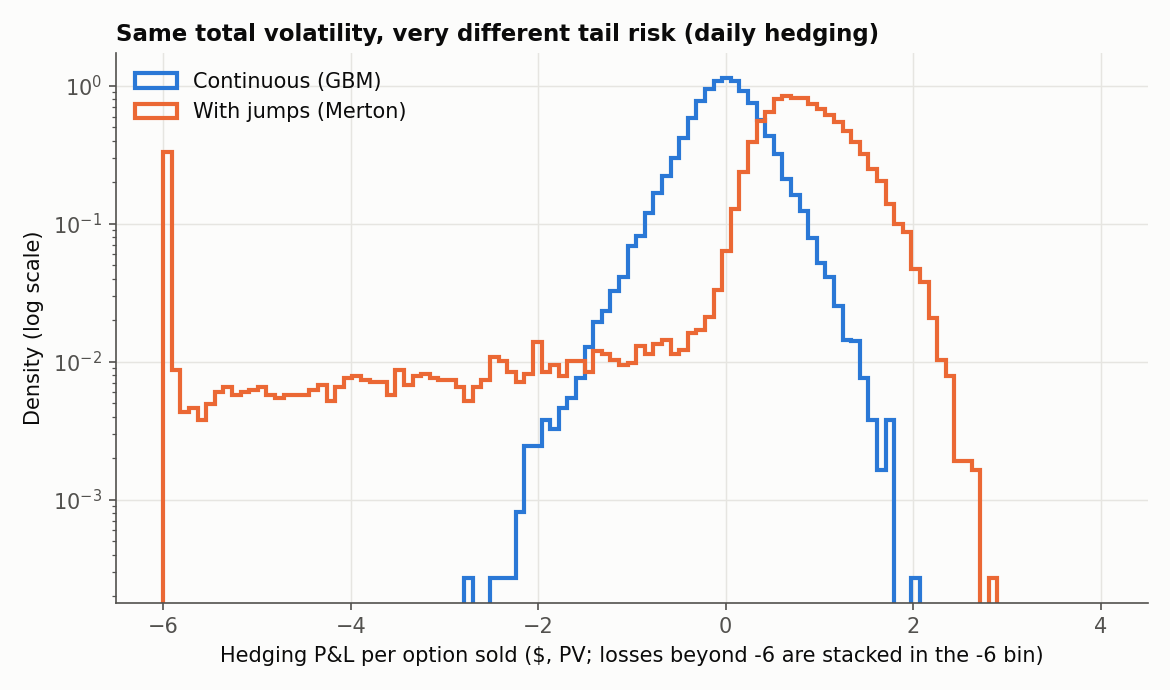

In [11]:
j = R['hedging']['jumps']; display(pd.DataFrame({'GBM':[j['gbm_std'],j['gbm_p1'],j['gbm_worst'],j['gbm_excess_kurtosis']],'Merton jumps':[j['jump_std'],j['jump_p1'],j['jump_worst'],j['jump_excess_kurtosis']]},index=['std','1st pct','worst','excess kurtosis']).round(3)); fig('hedge_C_jumps.png')

The jump mean P&L is positive because variance-matched Black-Scholes slightly over-prices the at-the-money option relative to Merton; the tail losses are far worse. Mean alone would be misleading.

**D. Transaction costs (5 bp) trade off against risk.**

,rebalances,mean_net_pnl,std_net_pnl,mean_cost
0,3,-0.0535,1.8100,0.0472
1,6,-0.0695,1.3102,0.0614
2,12,-0.0888,0.9496,0.0794
3,24,-0.1104,0.6802,0.1032
4,60,-0.1528,0.4398,0.1491
5,120,-0.2028,0.3200,0.2002
6,240,-0.2742,0.2420,0.2722


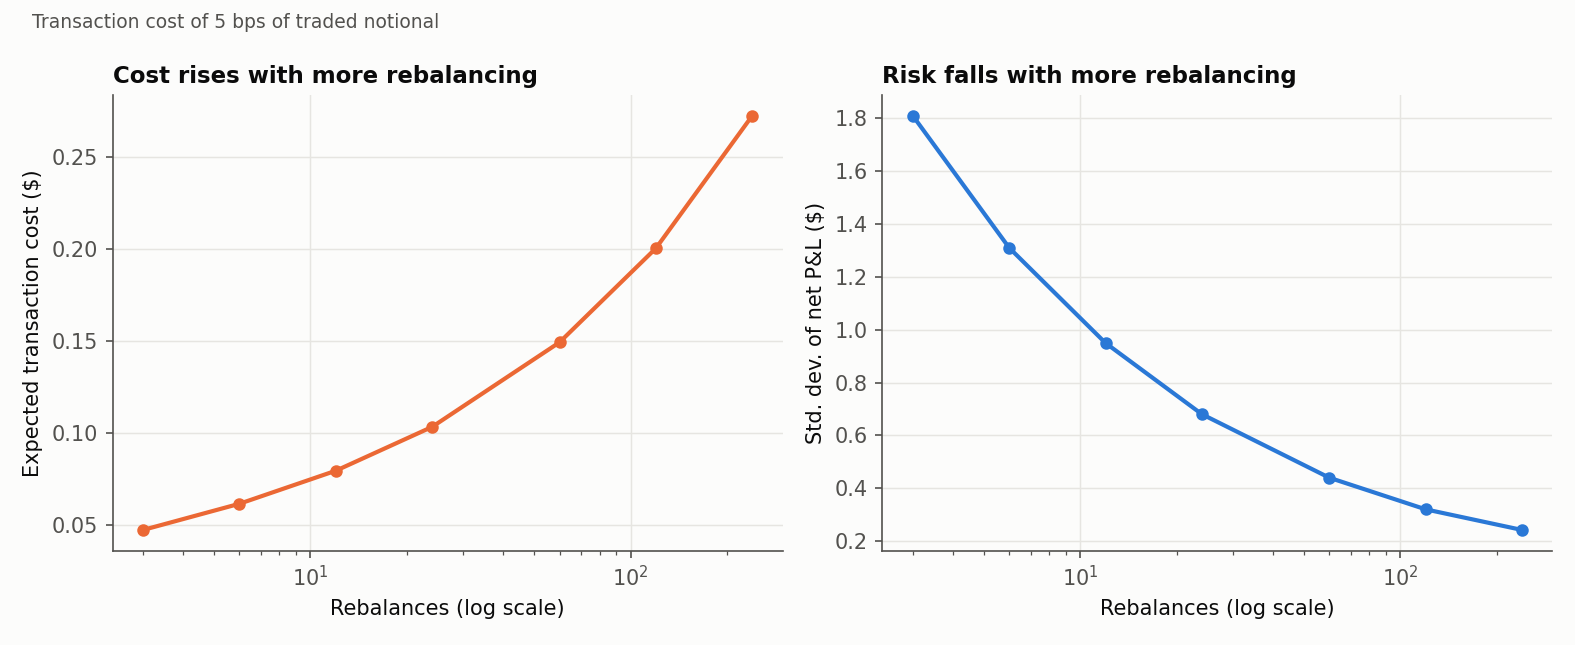

In [12]:
display(T_('hedge_D_costs.csv').round(4)); fig('hedge_D_costs.png')

## Takeaways
* The three pricers agree to within sampling error, and the Greeks match finite differences.
* Hedge error falls with 1/sqrt(rebalances); hedging at the wrong volatility produces a P&L that matches theory.
* Jumps create fat left tails that rebalancing cannot remove.
* Costs rise with trading frequency, so there is an optimal frequency.

**Not done here:** calibration to a real market, dividends, stochastic volatility. See the README for how to run the real-data scripts.